In [27]:
%load_ext autoreload
%autoreload 2

import numpy as np
from math import sqrt
import importlib

import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI

from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
import pandas as pd
from matplotlib import pyplot as plt

from causal_graph_comparison.subsample import subsample_outputs
from causal_graph_comparison import *
import causal_graph_comparison.utils as utils
importlib.reload(utils)
flatten_temporal_adjacency_graph = utils.flatten_temporal_adjacency_graph

from climatem.data_loader.causal_datamodule import CausalClimateDataModule
import torch

import gadjid
from gadjid import example, ancestor_aid, oset_aid, parent_aid, shd, sid
from causal_graph_comparison.utils import binarize_array
from causal_graph_comparison import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
N_MODES = 4
TAU_MAX = 5
LAT = 40
LON = 40
N_SAMPLES = 995

In [29]:
results_path = f"{SCRATCH_DIR}/results/SAVAR_DATA_TEST/STAR-var_savar_scen_piControl_nlinmix_False_nlindyn_False_tau_5_z_4_futt_1_ldec_1_lr_0.001_bs_256_ormuin_100000.0_spmuin_0.1_spth_0.05_nens_2_inst_False_crpscoef_1_sspcoef_0_tspcoef_0_fracnhiwn_0.5_nummix_0_numhid_0_embdim_10/bs_995_np_1_npp_1_t_50_sc_log_bayesian_temp_True/trajectory_iteration.npy"
gt_path = f"{SCRATCH_DIR}/results/SAVAR_DATA_TEST/STAR-var_savar_scen_piControl_nlinmix_False_nlindyn_False_tau_5_z_4_futt_1_ldec_1_lr_0.001_bs_256_ormuin_100000.0_spmuin_0.1_spth_0.05_nens_2_inst_False_crpscoef_1_sspcoef_0_tspcoef_0_fracnhiwn_0.5_nummix_0_numhid_0_embdim_10/bs_995_np_1_npp_1_t_50_sc_log_bayesian_temp_True/ground_truth_targets.npy"
picabu_output = np.load(results_path)
targets = np.load(gt_path)

picabu_output = picabu_output.squeeze()

print(picabu_output.shape)
print(targets.shape)

(50, 995, 1600)
(995, 1, 1600)


In [31]:
targets_50 = []
num_samples = picabu_output.shape[1]
num_timesteps = picabu_output.shape[0]
dims = picabu_output.shape[2]

print(f"num_samples: {num_samples}")

for i in range(num_samples - num_timesteps + 1):
    targets_50.append(targets[i:num_timesteps+i, :, :])

    # print(targets[i:num_timesteps+i, :, :].shape)
    # print(targets_50[i][1:5, : , 0].T)
    
targets_50 = np.array(targets_50)
num_samples = targets_50.shape[0]
targets_50 = targets_50.squeeze()
targets_50 = targets_50.reshape(num_timesteps, num_samples, dims)

print(targets_50.shape)


num_samples: 995
(50, 946, 1600)


In [35]:
# Spatial subsampling of outputs for dimensionality 50 timesteps

num_samples = targets_50.shape[1]
print(f"num_samples: {num_samples}")

n_modes_per_side = int(sqrt(N_MODES))

subsampled_outputs_50steps_2d = np.zeros((num_samples, num_timesteps, n_modes_per_side, n_modes_per_side))
subsampled_targets_50steps_2d = np.zeros((num_samples, num_timesteps, n_modes_per_side, n_modes_per_side))

for i in range(num_samples):
    subsampled_outputs_50steps_2d[i, :, :, :] = subsample_outputs(picabu_output[:, i, :], N_MODES)
    subsampled_targets_50steps_2d[i, :, :, :] = subsample_outputs(targets_50[:, i, :], N_MODES)

print("Shape of subsampled_outputs for 50 steps 2D: ", subsampled_outputs_50steps_2d.shape)
print("Shape of subsampled_targets for 50 steps 2D: ", subsampled_targets_50steps_2d.shape)

subsampled_outputs_50steps = subsampled_outputs_50steps_2d.reshape(num_samples, 50, 4)
subsampled_targets_50steps = subsampled_targets_50steps_2d.reshape(num_samples, 50, 4)

print("Shape of subsampled_outputs for 50 steps flattened: ", subsampled_outputs_50steps.shape)
print("Shape of subsampled_targets for 50 steps flattened: ", subsampled_targets_50steps.shape)

num_samples: 946
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50,

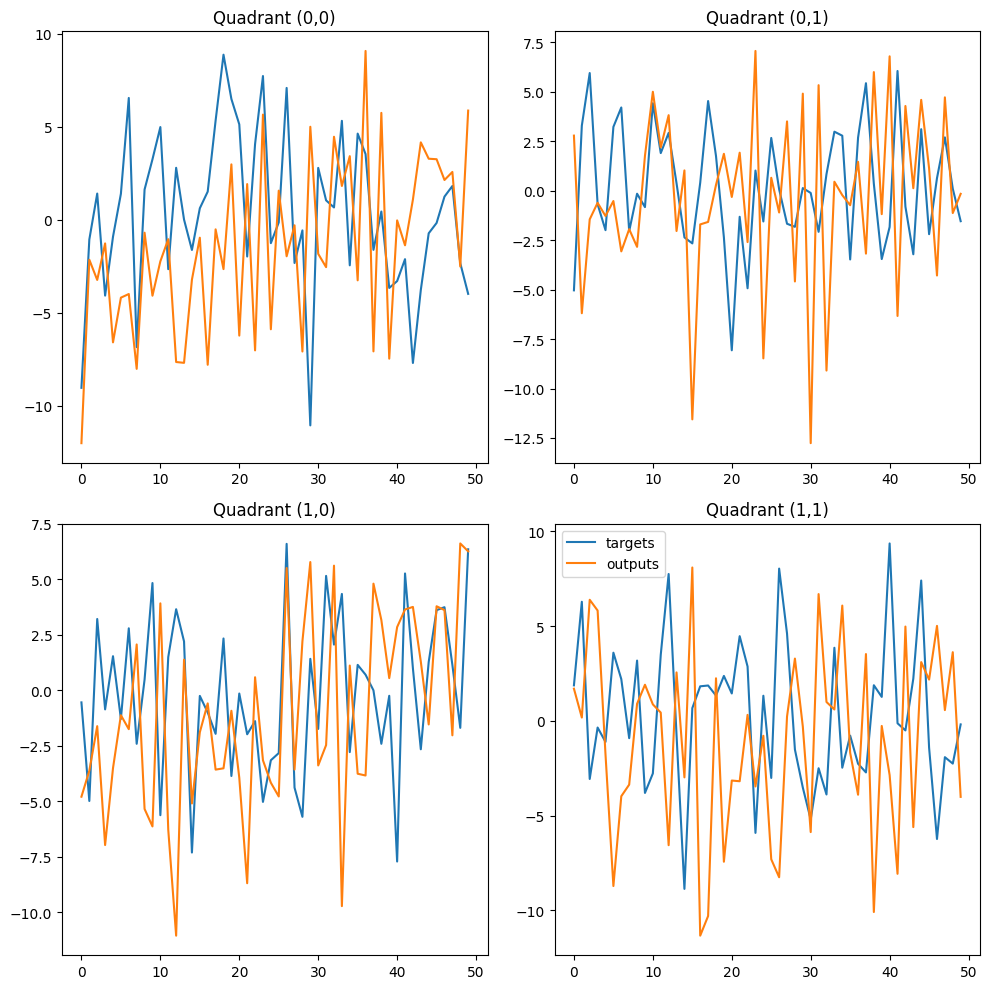

In [46]:
# Plot targets and outputs for all 4 quadrants

# for k in range(3):
plt.figure(figsize=(10, 10))
for i in range(2):
    for j in range(2):
        plt.subplot(2, 2, i*2 + j + 1)
        
        plt.plot(x_axis, subsampled_targets_50steps_2d[0, :, i, j], label="targets")
        plt.plot(x_axis, subsampled_outputs_50steps_2d[0, :, i, j], label="outputs")
        plt.title(f"Quadrant ({i},{j})")
plt.legend()
plt.tight_layout()
plt.show()


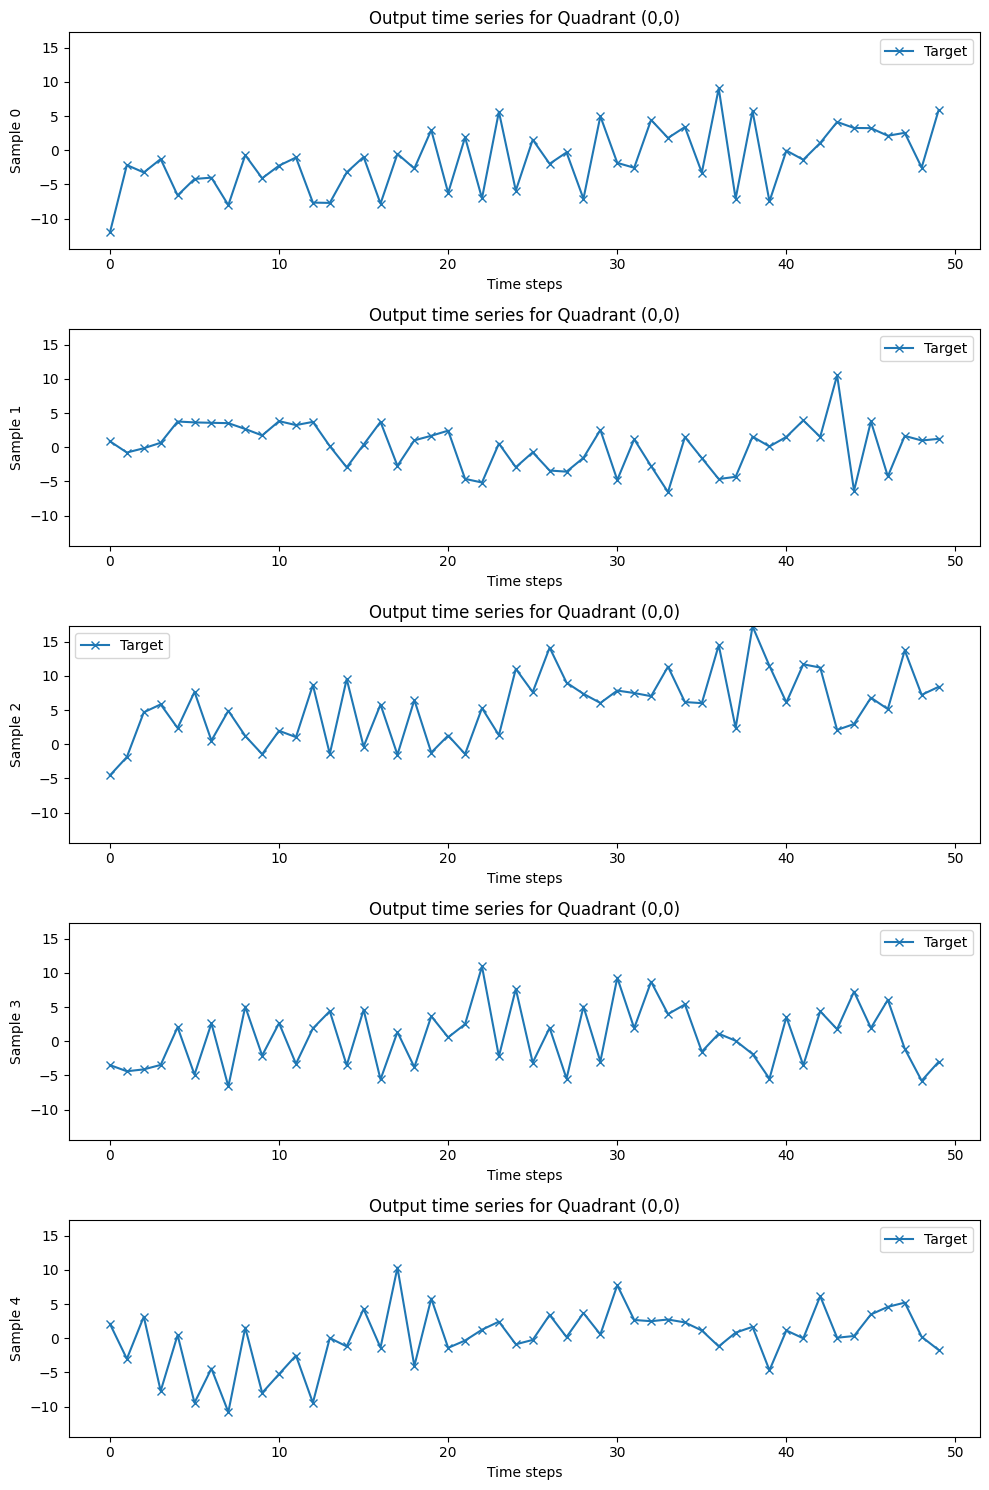

In [47]:
# Plot targets for 50 steps in quadrant 1 for the first 5 samples

y_values = subsampled_outputs_50steps_2d

# Plot targets and outputs for all quadrant 1
plt.figure(figsize=(10, 15))

# Find global min and max values across targets
all_values = []
for i in range(20):
    all_values.extend(y_values[0+i, :, 0, 0])
y_min, y_max = min(all_values), max(all_values)

for i in range(5):
    plt.subplot(5, 1, i+1)
    test_targets = y_values[0+i, :, 0, 0]

    # print(test_targets)
    
    # Create x-axis points for inputs and targets/outputs, shifted by i positions
    x_vals = np.arange(50)
    
    plt.plot(x_vals, test_targets, label="Target", marker='x')
    plt.ylabel(f"Sample {i}")
    plt.xlabel("Time steps")
    # plt.xticks(np.arange(50))  # Extended x-axis range to accommodate shifts
    plt.ylim(y_min, y_max)  # Set same y-axis limits for all subplots
    plt.title(f"Output time series for Quadrant ({0},{0})")
    plt.legend()

plt.tight_layout()
plt.show()



In [49]:
# Create variable names for the modes
var_names = [f"mode_{i}" for i in range(N_MODES)]
dataframe = pp.DataFrame(subsampled_outputs_50steps, analysis_mode = 'multiple', var_names=var_names)

In [50]:
print (dataframe.M)
print (dataframe.N)
print (dataframe.T)

946
4
{0: 50, 1: 50, 2: 50, 3: 50, 4: 50, 5: 50, 6: 50, 7: 50, 8: 50, 9: 50, 10: 50, 11: 50, 12: 50, 13: 50, 14: 50, 15: 50, 16: 50, 17: 50, 18: 50, 19: 50, 20: 50, 21: 50, 22: 50, 23: 50, 24: 50, 25: 50, 26: 50, 27: 50, 28: 50, 29: 50, 30: 50, 31: 50, 32: 50, 33: 50, 34: 50, 35: 50, 36: 50, 37: 50, 38: 50, 39: 50, 40: 50, 41: 50, 42: 50, 43: 50, 44: 50, 45: 50, 46: 50, 47: 50, 48: 50, 49: 50, 50: 50, 51: 50, 52: 50, 53: 50, 54: 50, 55: 50, 56: 50, 57: 50, 58: 50, 59: 50, 60: 50, 61: 50, 62: 50, 63: 50, 64: 50, 65: 50, 66: 50, 67: 50, 68: 50, 69: 50, 70: 50, 71: 50, 72: 50, 73: 50, 74: 50, 75: 50, 76: 50, 77: 50, 78: 50, 79: 50, 80: 50, 81: 50, 82: 50, 83: 50, 84: 50, 85: 50, 86: 50, 87: 50, 88: 50, 89: 50, 90: 50, 91: 50, 92: 50, 93: 50, 94: 50, 95: 50, 96: 50, 97: 50, 98: 50, 99: 50, 100: 50, 101: 50, 102: 50, 103: 50, 104: 50, 105: 50, 106: 50, 107: 50, 108: 50, 109: 50, 110: 50, 111: 50, 112: 50, 113: 50, 114: 50, 115: 50, 116: 50, 117: 50, 118: 50, 119: 50, 120: 50, 121: 50, 122: 

In [51]:
# STEP 4: Learn causal graph using PCMCI+

# Initialize PCMCI+
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr(),
    verbosity=1
)

# Run PCMCI+
results = pcmci.run_pcmciplus(
    tau_max=TAU_MAX,  # Maximum time lag
    tau_min=1,
    pc_alpha=0.01  # Significance level #TODO
)

n_gt_connections = 8 # TODO: get this from the GT causal graph in parameters csv file

# Extract results
graph = results['graph']
val_matrix = results['val_matrix']
p_matrix = results['p_matrix']



##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 5
pc_alpha = [0.01]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable mode_0 has 4 link(s):
        (mode_0 -2): max_pval = 0.00000, |min_val| =  0.575
        (mode_2 -4): max_pval = 0.00000, |min_val| =  0.484
        (mode_2 -5): max_pval = 0.00001, |min_val| =  0.023
        (mode_2 -3): max_pval = 0.00001, |min_val| =  0.023

    Variable mode_1 has 7 link(s):
        (mode_0 -4): max_pval = 0.00000, |min_val| =  0.275
        (mode_1 -2): max_pval = 0.00000, |min_val| =  0.153
        (mode_2 -5): max_pval = 0.00000, |min_val| =  0.029
        (mode_2 -4): max_pval = 0.00000, |min_val| =  0.025
        (mode_3 -3): max_pval = 0.00006, |min_val| =  0.021
        (mode_3 -1): max_pval = 0.00037, |min_val| =  0.018
        (mode_0 -2): max_pval = 0.00322, |min_val| =  0.015

    Variable mode_2 has 3 link(s):

In [52]:
dataframe.values

{0: array([[-12.01113224,   2.78903675,  -4.79824924,   1.70332074],
        [ -2.15379333,  -6.19255543,  -3.62803483,   0.18219963],
        [ -3.24008918,  -1.44447374,  -1.61755669,   6.39507437],
        [ -1.27832937,  -0.60755754,  -6.97841311,   5.82772827],
        [ -6.59373522,  -1.2761097 ,  -3.50950074,  -1.76861918],
        [ -4.1922431 ,  -0.51889026,  -1.12417054,  -8.70945835],
        [ -3.99727511,  -3.06470013,  -1.75284815,  -3.97174382],
        [ -8.01824856,  -1.94183373,   2.06615973,  -3.35905528],
        [ -0.70173705,  -2.8354671 ,  -5.35078001,   0.90750825],
        [ -4.08836794,   1.7697823 ,  -6.13868237,   1.91156316],
        [ -2.23893499,   5.00509644,   3.91962576,   0.87593621],
        [ -1.04984117,   2.19200563,  -6.28229666,   0.44167134],
        [ -7.65029907,   3.8209815 , -11.06398678,  -6.55408764],
        [ -7.69509363,  -2.03486204,   1.38103354,   2.5620997 ],
        [ -3.22498155,   1.02937293,  -5.10299206,  -2.9760673 ],
       

In [53]:
# Keep only the top 2 incoming values for each mode
print(f"\nFiltering to keep only top 2 incoming values per mode...")

# Create a copy of the original val_matrix
filtered_val_matrix = val_matrix.copy()
filtered_graph = graph.copy()

# For each target mode (each of the 4 modes)
for target_mode in range(val_matrix.shape[0]):
    print(f"\nProcessing incoming connections to mode {target_mode}:")
    
    # Collect all incoming values to this target mode
    # We need row 'target_mode' from each of the 4 matrices
    incoming_values = []
    incoming_positions = []
    
    for source_mode in range(val_matrix.shape[0]):  # source modes
        for lag in range(val_matrix.shape[2]):      # time lags
            value = val_matrix[source_mode, target_mode, lag]
            if value != 0:  # Only consider non-zero values
                incoming_values.append(abs(value))
                incoming_positions.append((source_mode, target_mode, lag))
    
    # Find the top 2 incoming connections
    if len(incoming_values) > 0:
        # Get indices of top 2 values
        top_indices = np.argsort(incoming_values)[-2:]
        
        print(f"Top 2 incoming connections to mode {target_mode}:")
        for idx in top_indices:
            source_mode, target_mode, lag = incoming_positions[idx]
            value = val_matrix[source_mode, target_mode, lag]
            print(f"  From mode {source_mode} to mode {target_mode} at lag {lag}: {value:.6f}")
    
    # Create a mask for all incoming connections to this target mode
    # Set all incoming connections to this target mode to 0/empty first
    for source_mode in range(val_matrix.shape[0]):
        for lag in range(val_matrix.shape[2]):
            filtered_val_matrix[source_mode, target_mode, lag] = 0
            filtered_graph[source_mode, target_mode, lag] = ""
    
    # Then restore only the top 2 incoming connections
    if len(incoming_values) > 0:
        for idx in top_indices:
            source_mode, target_mode, lag = incoming_positions[idx]
            filtered_val_matrix[source_mode, target_mode, lag] = val_matrix[source_mode, target_mode, lag]
            filtered_graph[source_mode, target_mode, lag] = graph[source_mode, target_mode, lag]

print(f"\nFiltered val_matrix shape: {filtered_val_matrix.shape}")
print(f"Total non-zero values in filtered matrix: {np.sum(filtered_val_matrix != 0)}")

# Print the filtered graph to see the remaining links
print(f"\nFiltered graph:")
print(filtered_graph)


Filtering to keep only top 2 incoming values per mode...

Processing incoming connections to mode 0:
Top 2 incoming connections to mode 0:
  From mode 2 to mode 0 at lag 4: 0.445618
  From mode 0 to mode 0 at lag 2: 0.461035

Processing incoming connections to mode 1:
Top 2 incoming connections to mode 1:
  From mode 1 to mode 1 at lag 2: 0.141374
  From mode 0 to mode 1 at lag 4: 0.228089

Processing incoming connections to mode 2:
Top 2 incoming connections to mode 2:
  From mode 2 to mode 2 at lag 3: 0.291507
  From mode 0 to mode 2 at lag 5: 0.335612

Processing incoming connections to mode 3:
Top 2 incoming connections to mode 3:
  From mode 3 to mode 3 at lag 3: 0.167279
  From mode 2 to mode 3 at lag 5: 0.557665

Filtered val_matrix shape: (4, 4, 6)
Total non-zero values in filtered matrix: 8

Filtered graph:
[[['' '' '-->' '' '' '']
  ['' '' '' '' '-->' '']
  ['' '' '' '' '' '-->']
  ['' '' '' '' '' '']]

 [['' '' '' '' '' '']
  ['' '' '-->' '' '' '']
  ['' '' '' '' '' '']
  [

In [54]:

print(f"\nPCMCI+ Results:")
print(f"Graph shape: {graph.shape}")
print(f"Value matrix shape: {val_matrix.shape}")
print(f"P-value matrix shape: {p_matrix.shape}")

# Print the discovered links
print(f"\nDiscovered causal links:")
for i in range(len(var_names)):
    for j in range(len(var_names)):
        for tau in range(TAU_MAX):
            if graph[i, j, tau] != "":
                print(f"{var_names[i]} <-{graph[i, j, tau]}- {var_names[j]} (lag {tau+1})")


PCMCI+ Results:
Graph shape: (4, 4, 6)
Value matrix shape: (4, 4, 6)
P-value matrix shape: (4, 4, 6)

Discovered causal links:
mode_0 <--->- mode_0 (lag 3)
mode_0 <--->- mode_1 (lag 5)
mode_0 <--->- mode_2 (lag 5)
mode_1 <--->- mode_1 (lag 3)
mode_2 <--->- mode_0 (lag 4)
mode_2 <--->- mode_0 (lag 5)
mode_2 <--->- mode_1 (lag 5)
mode_2 <--->- mode_2 (lag 4)
mode_3 <--->- mode_1 (lag 4)
mode_3 <--->- mode_3 (lag 4)


In [55]:
# Step 5: Analyze mode relationships

print(f"\nStep 5: Analyzing mode relationships...")

# Calculate correlations between modes
correlations = np.corrcoef(subsampled_outputs_50steps.reshape(-1, 4).T)

print(f"\nCorrelation matrix between modes:")
print(pd.DataFrame(correlations, index=var_names, columns=var_names))

# Count causal links per mode
print(f"\nCausal link counts per mode:")
for i, mode in enumerate(var_names):
    incoming = np.sum(graph[i, :, :] != "")
    outgoing = np.sum(graph[:, i, :] != "")
    print(f"{mode}: {incoming} incoming, {outgoing} outgoing links")



Step 5: Analyzing mode relationships...

Correlation matrix between modes:
          mode_0    mode_1    mode_2    mode_3
mode_0  1.000000  0.230247  0.184060  0.158324
mode_1  0.230247  1.000000  0.125602  0.156086
mode_2  0.184060  0.125602  1.000000  0.128643
mode_3  0.158324  0.156086  0.128643  1.000000

Causal link counts per mode:
mode_0: 4 incoming, 4 outgoing links
mode_1: 1 incoming, 5 outgoing links
mode_2: 7 incoming, 3 outgoing links
mode_3: 2 incoming, 2 outgoing links



Step 6: Plotting causal graph...


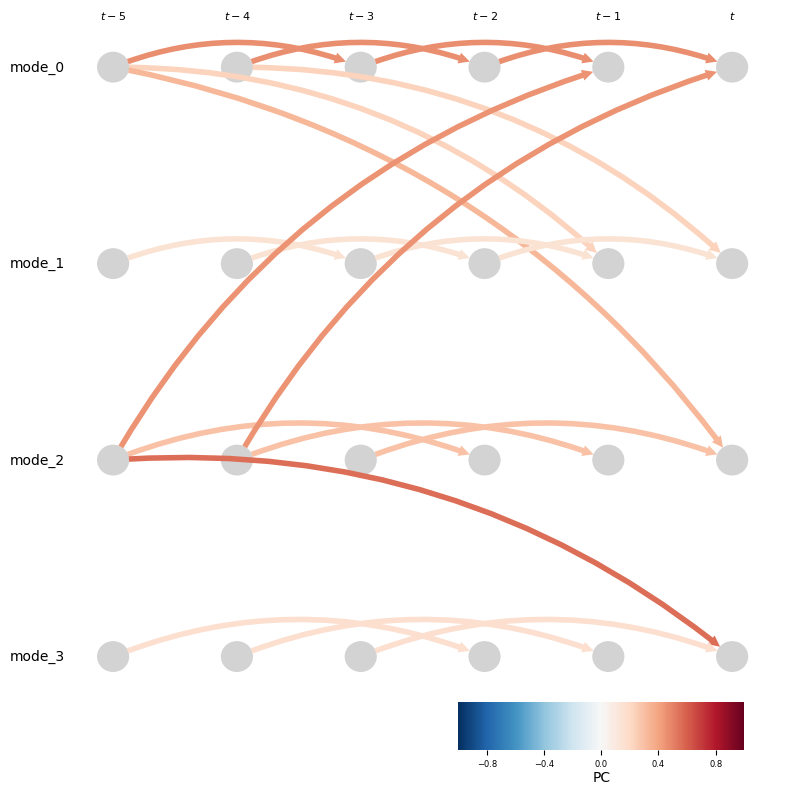

In [56]:
# Step 6: Plot causal graph
print(f"\nStep 6: Plotting causal graph...")

# Plot graph for each lag
tp.plot_time_series_graph(
    graph = filtered_graph,
    val_matrix=filtered_val_matrix,
    figsize=(8, 8),
    node_size=0.05,
    var_names=var_names,
    link_colorbar_label='PC')

plt.tight_layout()
# plt.savefig("causal_graph_example.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [60]:
gt_val_matrix = np.array([[[0., 0., 0.35592605, 0., 0., 0.],
  [0., 0., 0., 0., 0.15483783, 0.],
  [0., 0., 0., 0., 0., 0.15882398],
  [0., 0., 0., 0., 0., 0.]],

 [[0., 0., 0., 0., 0., 0.],
  [0., 0., 0.13968431, 0., 0., 0.],
  [0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0., 0., 0.]],

 [[0., 0., 0., 0., 0.27117607, 0.],
  [0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0.19788954, 0., 0.],
  [0., 0., 0., 0., 0., 0.2376847]],

 [[0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0., 0., 0.],
  [0., 0., 0., 0.20481765, 0., 0.]]])

In [61]:
G_true_flattened = binarize_array(flatten_temporal_adjacency_graph(gt_val_matrix))
G_guess_flattened = binarize_array(flatten_temporal_adjacency_graph(filtered_val_matrix))

print("G_true_flattened: ", G_true_flattened)
print("type of G_true_flattened: ", type(G_true_flattened))

G_true_flattened:  [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 

In [62]:
# -- 4. Calculate metrics --
print("parent_aid: ",   parent_aid(G_true_flattened, G_guess_flattened, edge_direction="from row to column"))
print("ancestor_aid: ", ancestor_aid(G_true_flattened, G_guess_flattened, edge_direction="from row to column"))
print("oset_aid: ", oset_aid(G_true_flattened, G_guess_flattened, edge_direction="from row to column"))
print("sid: ", sid(G_true_flattened, G_guess_flattened, edge_direction="from row to column"))
print("shd: ", shd(G_true_flattened, G_guess_flattened))

parent_aid:  (0.0, 0)
ancestor_aid:  (0.0, 0)
oset_aid:  (0.0, 0)
sid:  (0.0, 0)
shd:  (0.0, 0)
